In [ ]:
import pandas as pd
import numpy as np
player_valuations = pd.read_csv('../data/player_valuations.csv')
players = pd.read_csv('../data/players.csv')
appearances = pd.read_csv('../data/appearances.csv')
player_valuations['date'] = pd.to_datetime(player_valuations['date'])
appearances['date'] = pd.to_datetime(appearances['date'])
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'])
max_date = player_valuations['date'].max()

In [15]:
fresh_days = [90, 180, 365, 540]
current_valuations = player_valuations.sort_values(by='date').groupby('player_id').tail(1)[['player_id', 'market_value_in_eur', 'date']].rename(columns={'market_value_in_eur': 'current_value', 'date': 'current_date'})
current_valuations['days_since_update'] = (max_date - current_valuations['current_date']).dt.days
for i in fresh_days:
    fresh_valuations =current_valuations[current_valuations['days_since_update'] <= i].copy()
    print(f"Days since update: {i}, number of players: {len(fresh_valuations)}")

Days since update: 90, number of players: 5515
Days since update: 180, number of players: 5817
Days since update: 365, number of players: 6005
Days since update: 540, number of players: 6037


In [16]:
def build_dataset(fresh_days):
    current_valuations = player_valuations.sort_values(by='date').groupby('player_id').tail(1)[['player_id', 'market_value_in_eur', 'date']].rename(columns={'market_value_in_eur': 'current_value', 'date': 'current_date'})
    current_valuations['days_since_update'] = (max_date - current_valuations['current_date']).dt.days
    fresh_valuations = current_valuations[current_valuations['days_since_update'] <= fresh_days].copy()
    appearances_dated = appearances.merge(fresh_valuations[['player_id', 'current_date']], on='player_id', how='inner')
    appearances_valid = appearances_dated[appearances_dated['date'] <= appearances_dated['current_date']]
    
    stats = appearances_valid.groupby('player_id').agg(
        total_goals=('goals', 'sum'),
        total_assists=('assists', 'sum'),
        total_minutes=('minutes_played', 'sum'),
        total_appearances=('appearance_id', 'count'),
        total_yellow_cards=('yellow_cards', 'sum'),
        total_red_cards=('red_cards', 'sum')
    ).reset_index()
    df = fresh_valuations.merge(stats, on='player_id', how='inner')
    df = df.merge(
        players[['player_id', 'date_of_birth', 'position', 'sub_position', 'foot', 'height_in_cm']],
        on='player_id', how='inner'
    )
    
    df['age'] = (df['current_date'] - df['date_of_birth']).dt.days / 365.25
    df['foot'] = df['foot'].fillna('unknown')
    df['height_in_cm'] = df.groupby('position')['height_in_cm'].transform(lambda x: x.fillna(x.median()))
    df = df.dropna(subset=['age', 'sub_position'])
    
    df['goals_per_90'] = df['total_goals'] * 90 / df['total_minutes']
    df['assists_per_90'] = df['total_assists'] * 90 / df['total_minutes']
    df['log_value'] = np.log1p(df['current_value'])
    df['age_squared'] = df['age'] ** 2
    
    return df

In [ ]:
days = [90, 180, 365, 540]
data_summary = []
dataset_dict = {}
for fresh_days in days:
    df = build_dataset(fresh_days)
    dataset_dict[fresh_days] = df
    datarows = {
        'days': fresh_days,
        'players': len(df),
        'median_value': df['current_value'].median(),
        'mean_value': df['current_value'].mean(),
        'median_log_value': df['log_value'].median(),
        'attack': (df['position'] == 'Attack').mean(),
        'midfield': (df['position'] == 'Midfield').mean(),
        'defender': (df['position'] == 'Defender').mean(),
        'goalkeeper': (df['position'] == 'Goalkeeper').mean()}
    data_summary.append(datarows)
results_df = pd.DataFrame(data_summary)
print(results_df)

   days  players  median_value    mean_value  median_log_value  pct_attack  \
0    90     5173     1300000.0  5.918892e+06         14.077876    0.279528   
1   180     5447     1200000.0  5.654233e+06         13.997833    0.280705   
2   365     5585     1000000.0  5.529667e+06         13.815512    0.281110   
3   540     5610     1000000.0  5.506331e+06         13.815512    0.280392   

   pct_midfield  pct_defender  pct_goalkeeper  
0      0.295187      0.331916        0.093369  
1      0.295392      0.331375        0.092528  
2      0.295255      0.329454        0.094181  
3      0.295009      0.330125        0.094474  


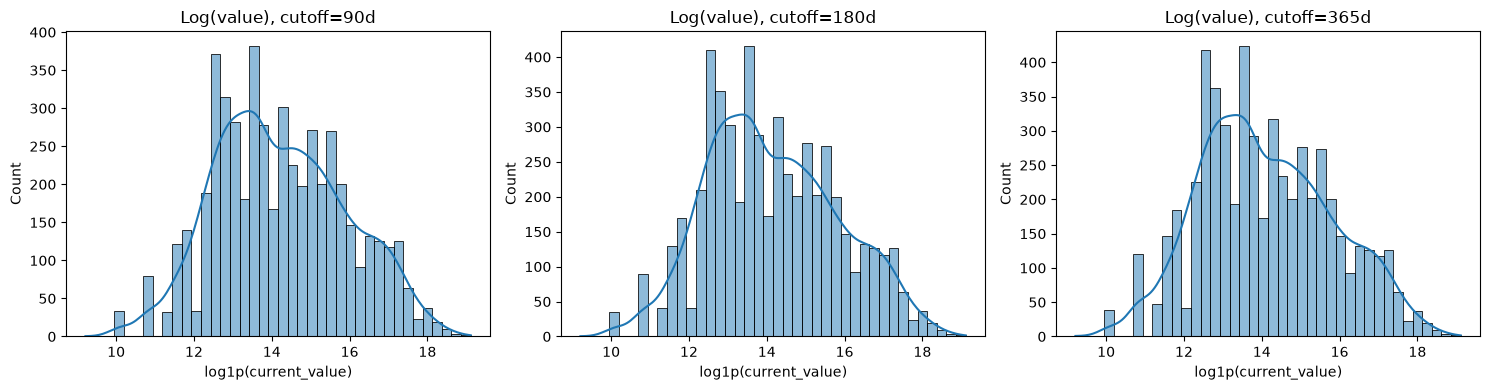

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cutoff in zip(axes, days):
    sns.histplot(np.log1p(dataset_dict[cutoff]['current_value']), bins=40, kde=True, ax=ax)
    ax.set_title(f'log value , cutoff={cutoff} days')
    ax.set_xlabel('log1p(current_value)')

plt.tight_layout()

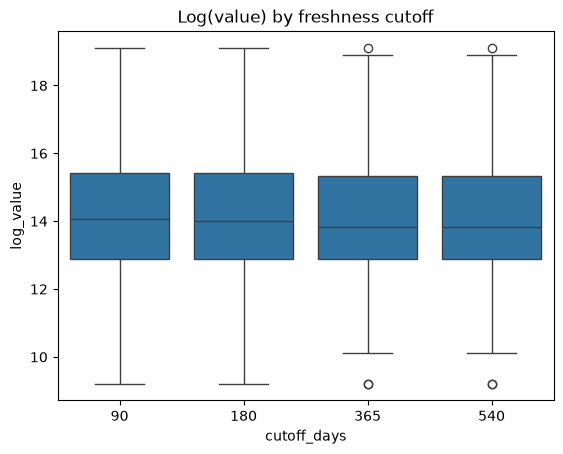

In [ ]:
combined = pd.concat([dataset_dict[c].assign(cutoff_days=c) for c in days], ignore_index=True)

sns.boxplot(data=combined, x='cutoff_days', y='log_value')
plt.title('log value by freshness cutoff')
plt.show()